# About the Data

Dataset contain the sales data of different products in India.This data has been taken from the Kaggle dataset. Dataset contain informations regarding the age, state, product, occupation, marital_status, amount of purchase, product_id, customer name and Number of orders per userId.

This analysis will be a exploratory data analysis and we will try to figure out some important insights from the data in order to make a data driven decision.

# Ask Phase

### Bussiness Question

Identify trends in diwali sales data to apply insights to company X's marketing strategy.

### Shareholders

Following are the shareholders of the data

1. Company X's CFO and CEO
2. Company X's marketing team

### Important questions to analyze

1. How can marketing teams leverage Diwali sales data to enhance sales strategies?

2. Which age groups exhibit the strongest affinity for Diwali shopping?

3. Does marital status play a significant role in Diwali purchasing decisions?

4. Which Indian states present the most favorable advertising opportunities for company X to maximize Diwali sales?

5. What product categories are most sought after by consumers during Diwali?

# Prepare Phase

### Data
This dataset is taken from kaggle open source data <"/kaggle/input/diwali-sales-dataset/Diwali Sales Data.csv">.

### Data crediblity and integrity
Dataset contain 11,251 rows and 15 columns. This is a big data but we can not generalize the concept for whole population but will try to figure out some strong insights that could help the users of this report to increase their sales.

# Process Phase
I will focus my analysis in Python due to the accessibility, amount of data and to be able to create data visualization to share my results with stakeholders.
​
### Import required libraries
We will be using following libraries in order to clean and analyze the data.
* Pandas
* Numpy
* Matplotlib
* Seaborn
* Operating System (OS)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# import directory for kaggle data

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/diwali-sales-dataset/Diwali Sales Data.csv


### Importing dataset

In [2]:
file_name = "/kaggle/input/diwali-sales-dataset/Diwali Sales Data.csv"
data = pd.read_csv(file_name, encoding='latin1')

### Preview our dataset

In [3]:
data.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


### Check the Shape of the data

In [4]:
data.shape

(11251, 15)

This dataset contains 11251 rows and 15 columns


### Check the data info for any null values


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


# Data Cleaning Phase

As we can see there are two null columns having 0 values, so we will delete those two columns from our analysis.

In [6]:
data.drop(['Status', 'unnamed1'], axis = 1, inplace = True)

### Remove Duplicate values if any

In [7]:
data = data.drop_duplicates()

In [8]:
data.shape

(11243, 13)

__We can check that the number of rows has been decreased from 11251 to 10980. This shows tha the duplicate values have been terminated.__

### Check for any null values and remove them

If we found any null value we can fill it with mean value but in this case there are just 12 null values and we can not fill the amount with mean as well. Therefore we will remove those rows. 

In [9]:
pd.isnull(data).sum()

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

In [10]:
# Removing the null values from dataset

data.dropna(inplace = True)

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11231 entries, 0 to 11250
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11231 non-null  int64  
 1   Cust_name         11231 non-null  object 
 2   Product_ID        11231 non-null  object 
 3   Gender            11231 non-null  object 
 4   Age Group         11231 non-null  object 
 5   Age               11231 non-null  int64  
 6   Marital_Status    11231 non-null  int64  
 7   State             11231 non-null  object 
 8   Zone              11231 non-null  object 
 9   Occupation        11231 non-null  object 
 10  Product_Category  11231 non-null  object 
 11  Orders            11231 non-null  int64  
 12  Amount            11231 non-null  float64
dtypes: float64(1), int64(4), object(8)
memory usage: 1.2+ MB


### Data cleaning steps

To get some better view while analyzing and ploting the data let's just clean the data as per our need 

and more appealing.

We will change the data type of Amount and marital_status from float and object to intiger

Will also change the Marital staus values from 0, 1 to unmarried and married.

Will change the gender values from F and M to Female and Male.

In [12]:
# Change the data type of Amount and Marital_Status

data['Amount'] = data['Amount'].astype('int')

data['Marital_Status'] = data['Marital_Status'].astype('int')

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11231 entries, 0 to 11250
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   User_ID           11231 non-null  int64 
 1   Cust_name         11231 non-null  object
 2   Product_ID        11231 non-null  object
 3   Gender            11231 non-null  object
 4   Age Group         11231 non-null  object
 5   Age               11231 non-null  int64 
 6   Marital_Status    11231 non-null  int64 
 7   State             11231 non-null  object
 8   Zone              11231 non-null  object
 9   Occupation        11231 non-null  object
 10  Product_Category  11231 non-null  object
 11  Orders            11231 non-null  int64 
 12  Amount            11231 non-null  int64 
dtypes: int64(5), object(8)
memory usage: 1.2+ MB


In [14]:
#Convert the column into a dataframe so that we could change the values 0,1 with Unmarrie and married

df = pd.DataFrame(data)

#change the Marital staus values from 0, 1 to unmarried and married.

df['Marital_Status'] = df['Marital_Status'].replace({0: "Unmarried", 1: "Married"})

In [15]:
#change the gender values from F and M to Female and Male.

df['Gender'] = df['Gender'].replace({"F": "Female", "M": "Male"})

In [16]:
df

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,Female,26-35,28,Unmarried,Maharashtra,Western,Healthcare,Auto,1,23952
1,1000732,Kartik,P00110942,Female,26-35,35,Married,Andhra Pradesh,Southern,Govt,Auto,3,23934
2,1001990,Bindu,P00118542,Female,26-35,35,Married,Uttar Pradesh,Central,Automobile,Auto,3,23924
3,1001425,Sudevi,P00237842,Male,0-17,16,Unmarried,Karnataka,Southern,Construction,Auto,2,23912
4,1000588,Joni,P00057942,Male,26-35,28,Married,Gujarat,Western,Food Processing,Auto,2,23877
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,1000695,Manning,P00296942,Male,18-25,19,Married,Maharashtra,Western,Chemical,Office,4,370
11247,1004089,Reichenbach,P00171342,Male,26-35,33,Unmarried,Haryana,Northern,Healthcare,Veterinary,3,367
11248,1001209,Oshin,P00201342,Female,36-45,40,Unmarried,Madhya Pradesh,Central,Textile,Office,4,213
11249,1004023,Noonan,P00059442,Male,36-45,37,Unmarried,Karnataka,Southern,Agriculture,Office,3,206


### Check for the some important statistical insights of the data including the mean, standard deviation and count of values

In [17]:
df[['Age', 'Amount','Orders']].describe()

,Age,Amount,Orders
count,11231.000000,11231.000000,11231.000000
mean,35.411985,9454.084676,2.489093
std,12.756116,5221.728074,1.114880
min,12.000000,188.000000,1.000000
25%,27.000000,5443.000000,2.000000
50%,33.000000,8109.000000,2.000000
75%,43.000000,12677.500000,3.000000
max,92.000000,23952.000000,4.000000


# Exploring the data using visual insights

## Gender
In this part we will analyze the data base on the gender using count of orders and the total revenue amount.

__Graph the count of customers on basis of their gender__

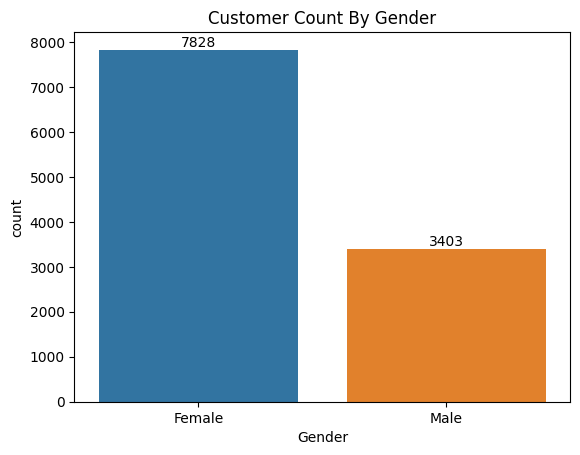

In [18]:
# plot the count of customers on basis of their gender
gender_count = sns.countplot(x = 'Gender', data = df)
plt.title("Customer Count By Gender")
# we can add lables to this chart

for bars in gender_count.containers:
    gender_count.bar_label(bars)

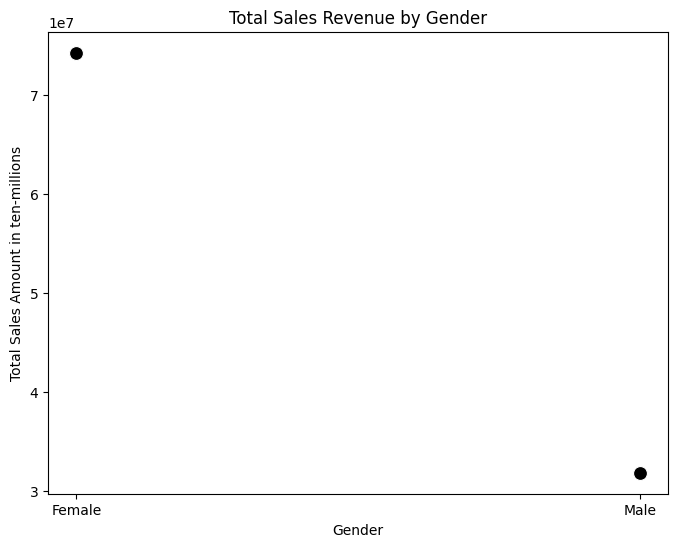

In [19]:
sales_gen = df.groupby(['Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

plt.figure(figsize=(8, 6))
sns.scatterplot(x='Gender', y='Amount', data=sales_gen, s=100, color='black')  # 's' parameter controls marker size
plt.title('Total Sales Revenue by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Sales Amount in ten-millions')
plt.show()

__Insights from Gender data__

As we can see the from above graphs the females are participating and are more interested in dewali sales than men. Also the purchasing power of Female is higher than male as the total sales revenue generated from female is much higher than that of male.

## Age Group

I will be ploting graphs and charts for different age group and their contribution towards total sales and also the how many customers are purchasing diwali products based on their age group.


__Total count of customers in each age-group data__

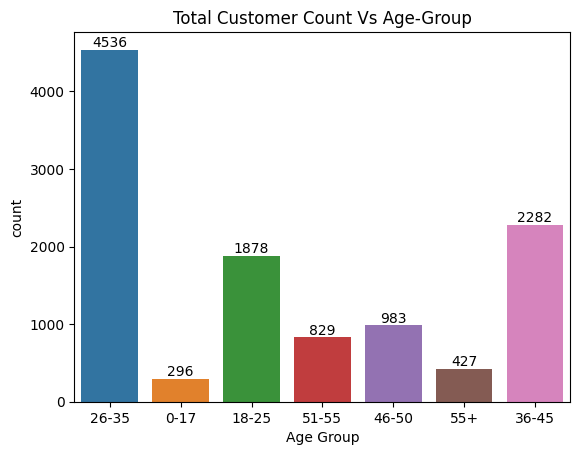

In [20]:
# Total count of customers in each age-group data 
age_group_count = sns.countplot(x = 'Age Group', data = df)
plt.title("Total Customer Count Vs Age-Group")

for bars in age_group_count.containers:
    age_group_count.bar_label(bars)
    

__plot the data for Total Revenue Generated by each Age-Group__

Text(0.5, 1.0, 'Total Revenue Generated by each Age-Group')

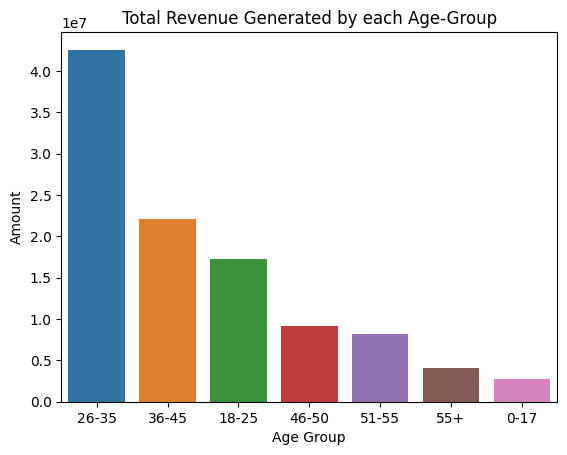

In [21]:
# group the data usinng Age Group and calculate the total amount generated by each age group
total_revenue_age = df.groupby(['Age Group'], as_index =False).sum('Amount').sort_values(by='Amount', ascending = False)

# plot the data

sns.barplot(x = 'Age Group', y = 'Amount', data = total_revenue_age)
plt.title("Total Revenue Generated by each Age-Group")

__We have devided the count of sales on basis of male and female so now we can check for the actuall number of male and femal in each age group__

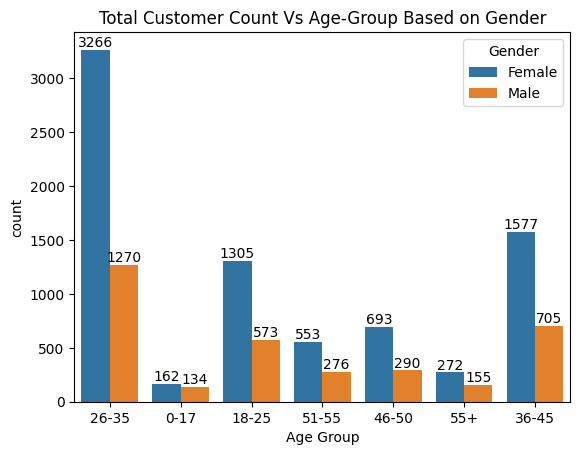

In [22]:
age_group_count = sns.countplot(x = 'Age Group', data = df, hue = 'Gender')
plt.title("Total Customer Count Vs Age-Group Based on Gender")
for bars in age_group_count.containers:
    age_group_count.bar_label(bars)

In [23]:
# group the data on basis of age group so that we could later use this dataframe

grouped_df = df.groupby("Age Group")

In [24]:
sum_of_revenue = grouped_df["Amount"].sum()

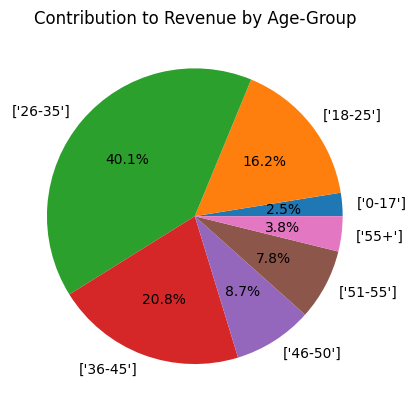

In [25]:
plt.pie(sum_of_revenue, labels = grouped_df["Age Group"].unique(), autopct="%1.1f%%")
plt.title("Contribution to Revenue by Age-Group")
plt.show()

__Findings from Age group data__

We can see from above graphsthat most our customers are females and fall in age group of 26-35. Customers from age group of 26-35 are generating the more than 40% of total Revenue. Also the graphs clarify us that the female customer are more dominating in purchasing diwali products than male.

In [26]:
# check the columns once again to see the column names
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

In [27]:
# Creating a new dataframe named as df3 and sort the values by age in ascending order
df3 = df.sort_values(
      by = "Age", ascending = True)

In [28]:
# Create a new dataframe named as grouped_df2 and group the data of df3 by age # we will use these datas later as well if needed
grouped_df2 = df3.groupby("Age")

In [29]:
sum_of_revenue = grouped_df2["Amount"].sum()

In [30]:
# Create a variable x with all the unique value of age in ascending order and now our data is ready to be ploted using matplotlib
x = df3["Age"].unique()

In [31]:
# just check it out that everything is according to our need, so let's go ahead
x

array([12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28,
       29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45,
       46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62,
       63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79,
       80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92])

Text(0.5, 1.0, 'Sum of Revenue by Age')

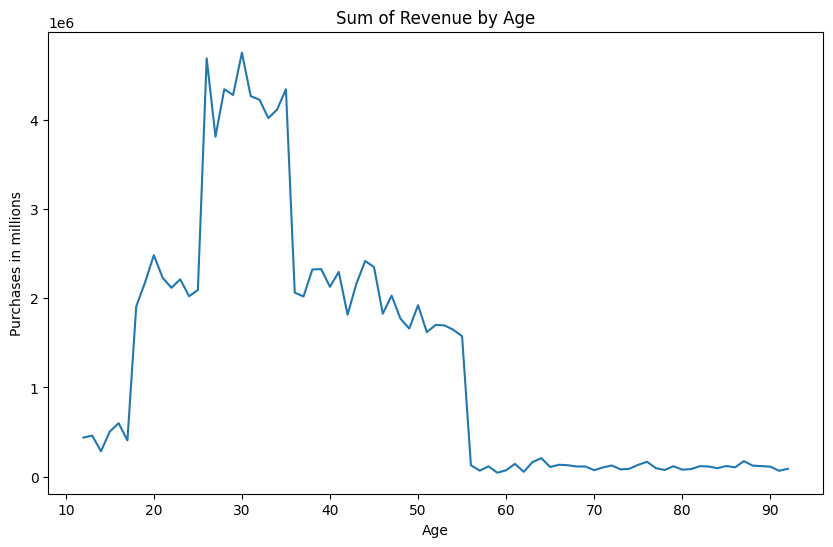

In [32]:
plt.figure(figsize=(10,6))
plt.plot(x, sum_of_revenue)
plt.xlabel("Age")
plt.ylabel("Purchases in millions")
plt.title("Sum of Revenue by Age")

__Insights From Age__

As we can see from the graph that age group of 30 and around 30 are purchasing more than the rest of consumers. Old age people are least active buyers.

In [33]:
# Lets see the column name again__
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

## State
__Now we will analyze the data to get the top 5 States that have highest sale__


In [34]:
# First of all again make the data ready for ploting. So we will group the data by states and then check for the sum of revenue 
# generated from each state

grouped_state = df.groupby("State").sum("Amount")
print(grouped_state)

                     User_ID    Age  Orders    Amount
State                                                
Andhra Pradesh     813444768  28862    2051   8037146
Bihar              434276128  15388    1058   4014669
Delhi             1107443106  39245    2740  11603818
Gujarat            427277619  15446    1063   3938159
Haryana            452368496  15830    1106   4217871
Himachal Pradesh   609750920  21618    1568   4963368
Jharkhand          381174335  13564     953   3026456
Karnataka         1307886059  46006    3240  13523540
Kerala             454335141  15625    1137   3894491
Madhya Pradesh     923841712  32991    2252   8101142
Maharashtra       1526613269  52624    3798  14404467
Punjab             200583317   6906     495   1525800
Rajasthan          231693815   7971     555   1909409
Telangana          125361330   4710     312   1151490
Uttar Pradesh     1947736750  69108    4803  19346055
Uttarakhand        320951452  11818     824   2520944


**Will plot a bar graph for states based on revenue generated**

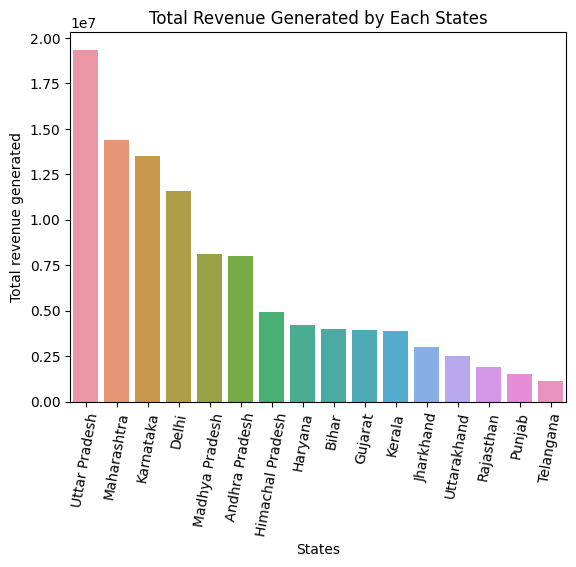

In [35]:
total_revenue_state = df.groupby(['State'], as_index =False).sum('Amount').sort_values(by='Amount', ascending = False)

# plot the data

states_plot = sns.barplot(x = 'State', y = 'Amount', data = total_revenue_state)
plt.title("Total Revenue Generated by Each States")
plt.ylabel("Total revenue generated")
plt.xlabel("States")
plt.xticks(rotation = 80)
plt.rcParams["figure.figsize"] = (35,6)

__Will plot a bar graph for total orders placed by each States__

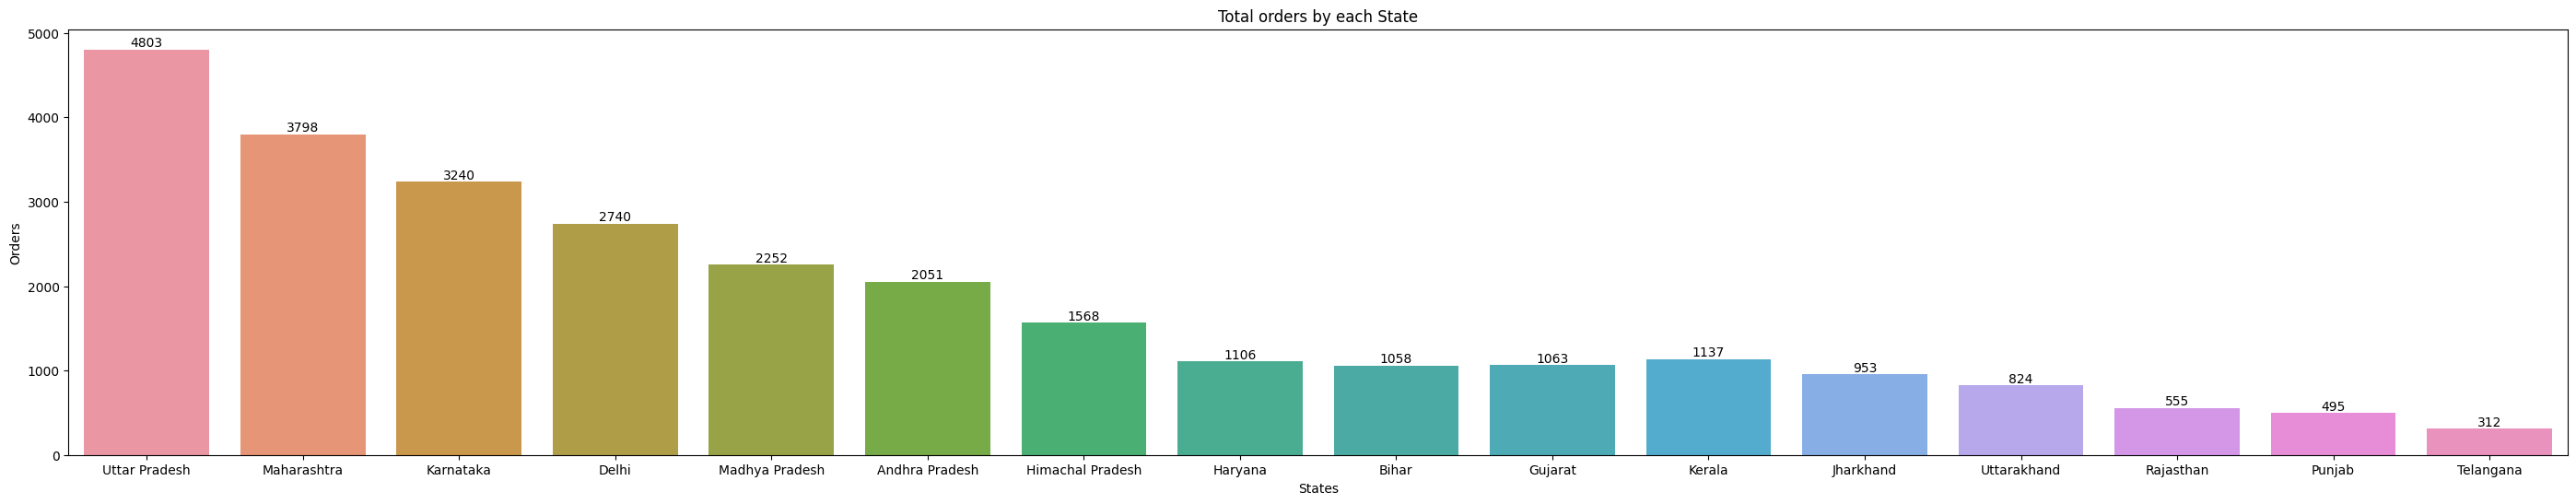

In [36]:
total_order_state = df.groupby(['State'], as_index =False).sum('Orders').sort_values(by='Orders', ascending = False).head(5)

# plot the data

states_plot = sns.barplot(x = 'State', y = 'Orders', data = total_revenue_state)
plt.title("Total orders by each State")
plt.xlabel("States")

for bars in states_plot.containers:
    states_plot.bar_label(bars)

__Insights From States__
We can observe the graphs showing 5 states of India with highest sales, these states are Uttar Pradesh, Maharashtra, Karnataka, Dehli and Mahya Pradesh.

__Lets check the data for Average order price in each state and graph them__

In [37]:
# create a variable and use this variable colmn data  to visualize the data of average price in each states

average_order_price = grouped_state["Amount"]/grouped_state["Orders"]

In [38]:
average_order_price.head(5)

State
Andhra Pradesh    3918.647489
Bihar             3794.583176
Delhi             4234.970073
Gujarat           3704.759172
Haryana           3813.626582
dtype: float64

In [39]:
# Create a variable k to add it later in graph data
k = grouped_state
print(k)

                     User_ID    Age  Orders    Amount
State                                                
Andhra Pradesh     813444768  28862    2051   8037146
Bihar              434276128  15388    1058   4014669
Delhi             1107443106  39245    2740  11603818
Gujarat            427277619  15446    1063   3938159
Haryana            452368496  15830    1106   4217871
Himachal Pradesh   609750920  21618    1568   4963368
Jharkhand          381174335  13564     953   3026456
Karnataka         1307886059  46006    3240  13523540
Kerala             454335141  15625    1137   3894491
Madhya Pradesh     923841712  32991    2252   8101142
Maharashtra       1526613269  52624    3798  14404467
Punjab             200583317   6906     495   1525800
Rajasthan          231693815   7971     555   1909409
Telangana          125361330   4710     312   1151490
Uttar Pradesh     1947736750  69108    4803  19346055
Uttarakhand        320951452  11818     824   2520944


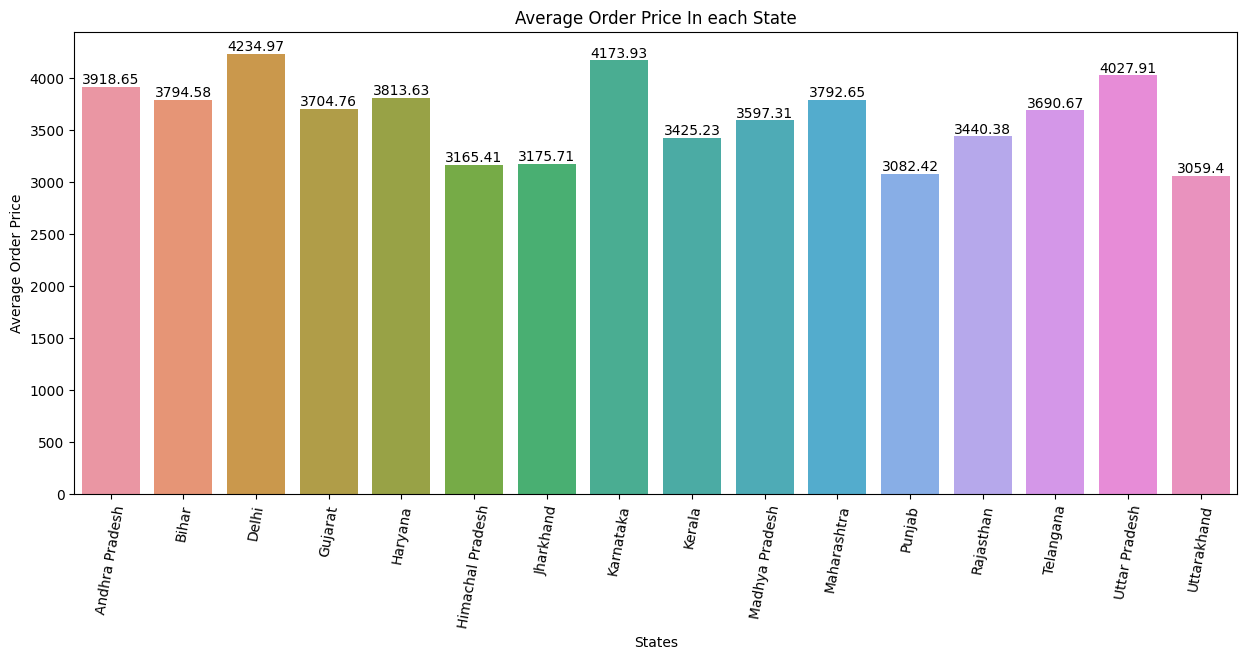

In [40]:
plt.figure(figsize=(15,6))
states_plot = sns.barplot(x = grouped_state.index, y = average_order_price, data = grouped_state)
plt.title("Average Order Price In each State")
plt.ylabel("Average Order Price")
plt.xlabel("States")
plt.xticks(rotation = 80)

for bars in states_plot.containers:
    states_plot.bar_label(bars)

__Insights From States data__

Although Maharasthra is leading state in generating more sales revenue but for per unit cost Dehli is at the top of list. This can be either due to the high average price charged in Dehli as compare to other states or Dehli people are purchasing more luxurios items costing them high prices.

## Marital Status
​
We will analyze the marital status data to find some insights and make a decision about marital status. Either married couples are more interested in diwali sales or the unmarried sector has large consumers of diwali sales.
​


__Graph the data for Total Revenue Generated by different marital status of customer__

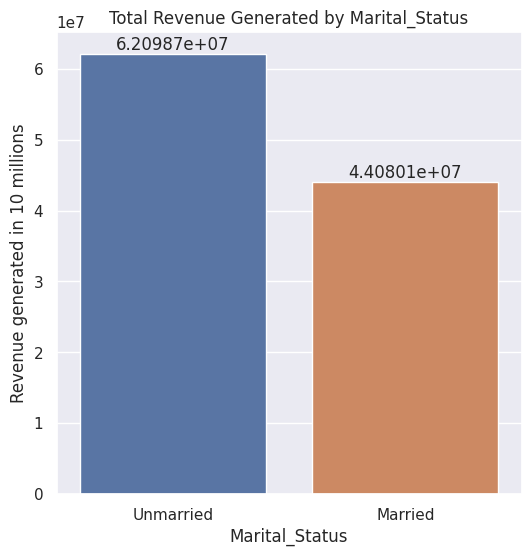

In [41]:
# plotting a bar graph for different marital status and see if there is any trend in the data for the married and unmarried 

status = df.groupby(['Marital_Status'],as_index = False).sum("Amount").sort_values(by= "Amount", ascending = False)

# plot the data
sns.set(rc={'figure.figsize':(6,6)})
status_plot = sns.barplot(x= 'Marital_Status', y = 'Amount', data = status)
plt.title("Total Revenue Generated by Marital_Status")
plt.ylabel("Revenue generated in 10 millions")

for bars in status_plot.containers:
    status_plot.bar_label(bars)

__Plot a bar graph for different marital status and see if there is any trend in the data for the married and unmarried based on the gender.__

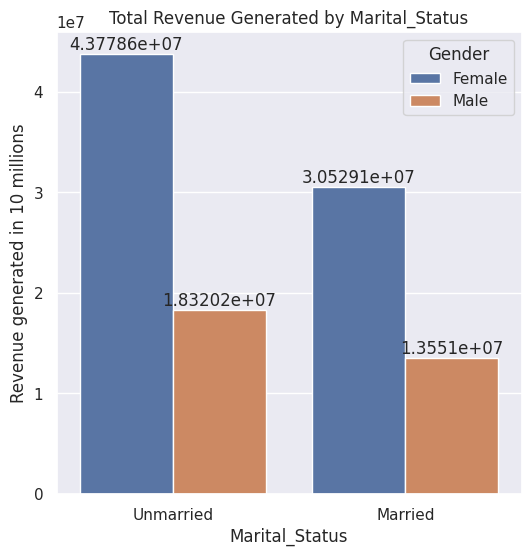

In [42]:
status = df.groupby(['Marital_Status', 'Gender'],as_index = False).sum("Amount").sort_values(by= "Amount", ascending = False)

# plot the data
sns.set(rc={'figure.figsize':(6,6)})
status_plot = sns.barplot(x= 'Marital_Status', y = 'Amount', data = status, hue ='Gender')
plt.title("Total Revenue Generated by Marital_Status")
plt.ylabel("Revenue generated in 10 millions")

for bars in status_plot.containers:
    status_plot.bar_label(bars)

__Insights from Marital_Status__

From the above graph and we can analyze that the most of sales are coming from Unmarried females and then second highest contribution to the sale is Married female

## Occupation
Now we will see persons from which occupation is more likely to praticipate in diwali sales offer.

​
__Graph a column chart for Total Cutomer count by customers profession__

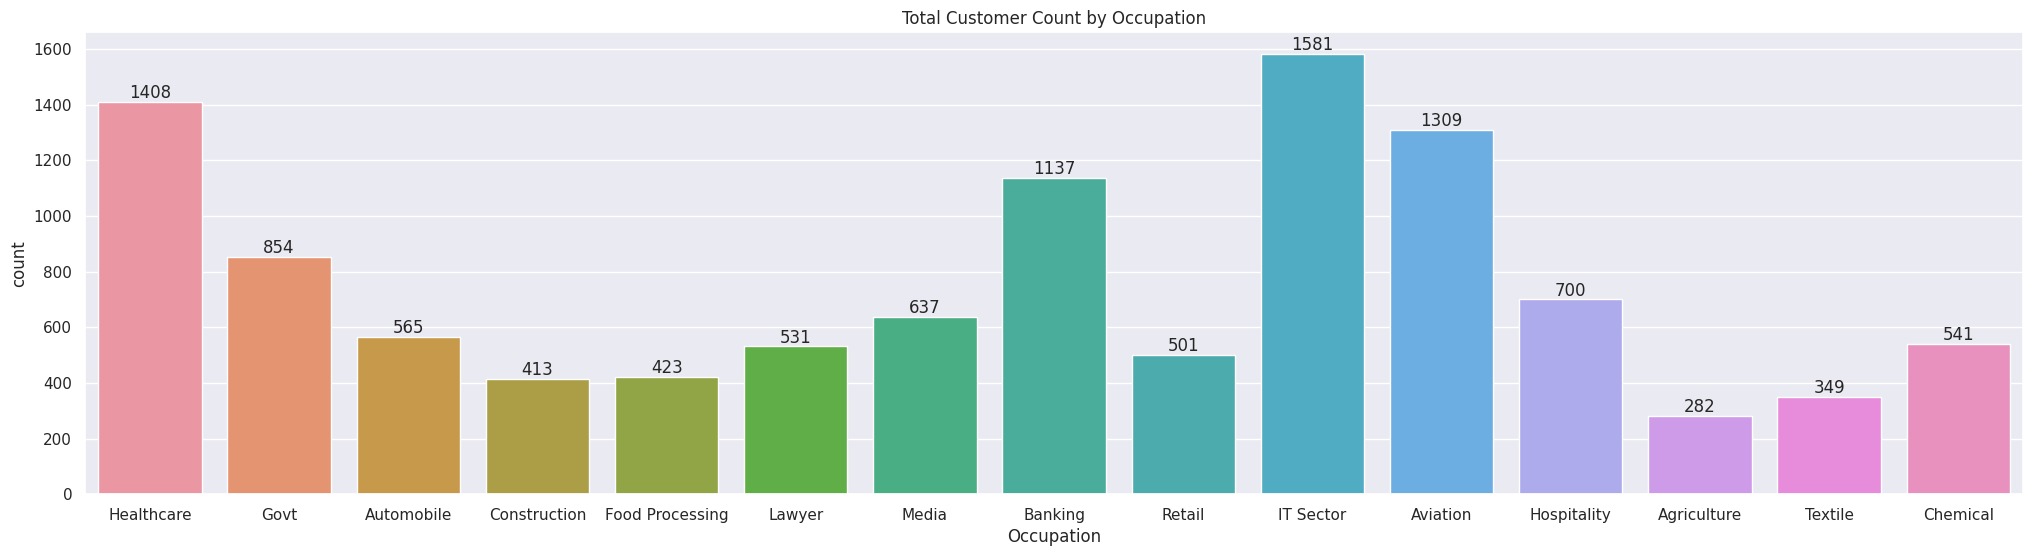

In [43]:
occupation = df.groupby(['Occupation'], as_index = False).sum("Amount").sort_values(by = 'Amount', ascending = False)

# plot the data on a bar graph
sns.set(rc={'figure.figsize':(25,6)})
occupation_plot = sns.countplot(data = df, x = 'Occupation')
plt.title("Total Customer Count by Occupation")

for bars in occupation_plot.containers:
    occupation_plot.bar_label(bars)

__Now we will check the top 5 Occupations that are contributing most to the revenue__

Text(0.5, 1.0, 'Top 5 Revenue Generated  Vs Occupation of customers')

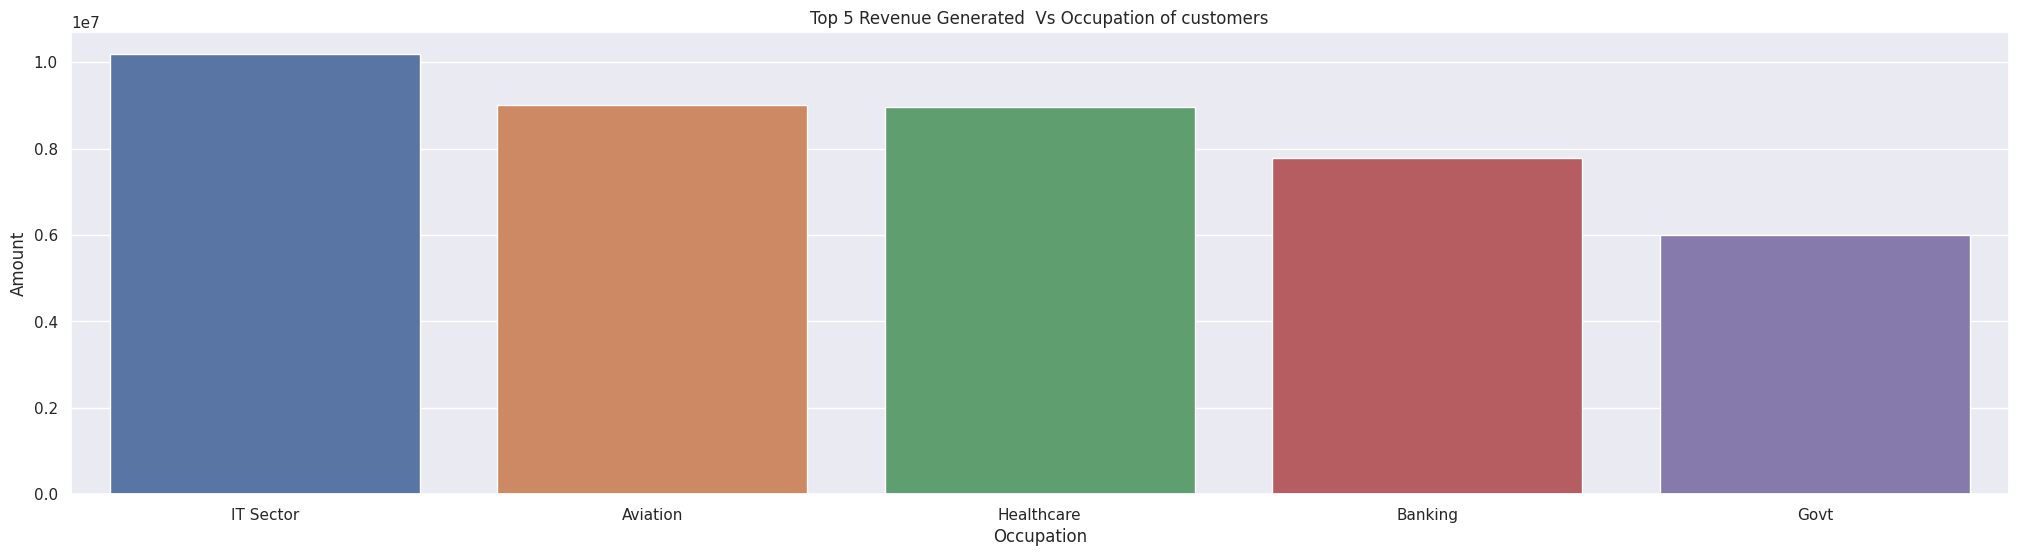

In [44]:
occupation_data = df.groupby(['Occupation', 'Gender'], as_index = False).sum("Amount").sort_values(by= 'Amount', ascending = False).head(5)

# plot the data

status_plot = sns.barplot(x= 'Occupation', y = 'Amount', data = occupation_data)
plt.title("Top 5 Revenue Generated  Vs Occupation of customers")


__Insights from Occupation__

As we observe the graph we noticed that the IT Sector generats the highest sales revenue and after that Aviation, Healthcare and then Banking and so on.

# Product Category

In order to see the sales of each category product we will use the data and check for the top 5 categories of product which has highest sales and which are contributing most to the total sales.

__plot a column graph to see which products have highest orders__

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17]),
 [Text(0, 0, 'Auto'),
  Text(1, 0, 'Hand & Power Tools'),
  Text(2, 0, 'Stationery'),
  Text(3, 0, 'Tupperware'),
  Text(4, 0, 'Footwear & Shoes'),
  Text(5, 0, 'Furniture'),
  Text(6, 0, 'Food'),
  Text(7, 0, 'Games & Toys'),
  Text(8, 0, 'Sports Products'),
  Text(9, 0, 'Books'),
  Text(10, 0, 'Electronics & Gadgets'),
  Text(11, 0, 'Decor'),
  Text(12, 0, 'Clothing & Apparel'),
  Text(13, 0, 'Beauty'),
  Text(14, 0, 'Household items'),
  Text(15, 0, 'Pet Care'),
  Text(16, 0, 'Veterinary'),
  Text(17, 0, 'Office')])

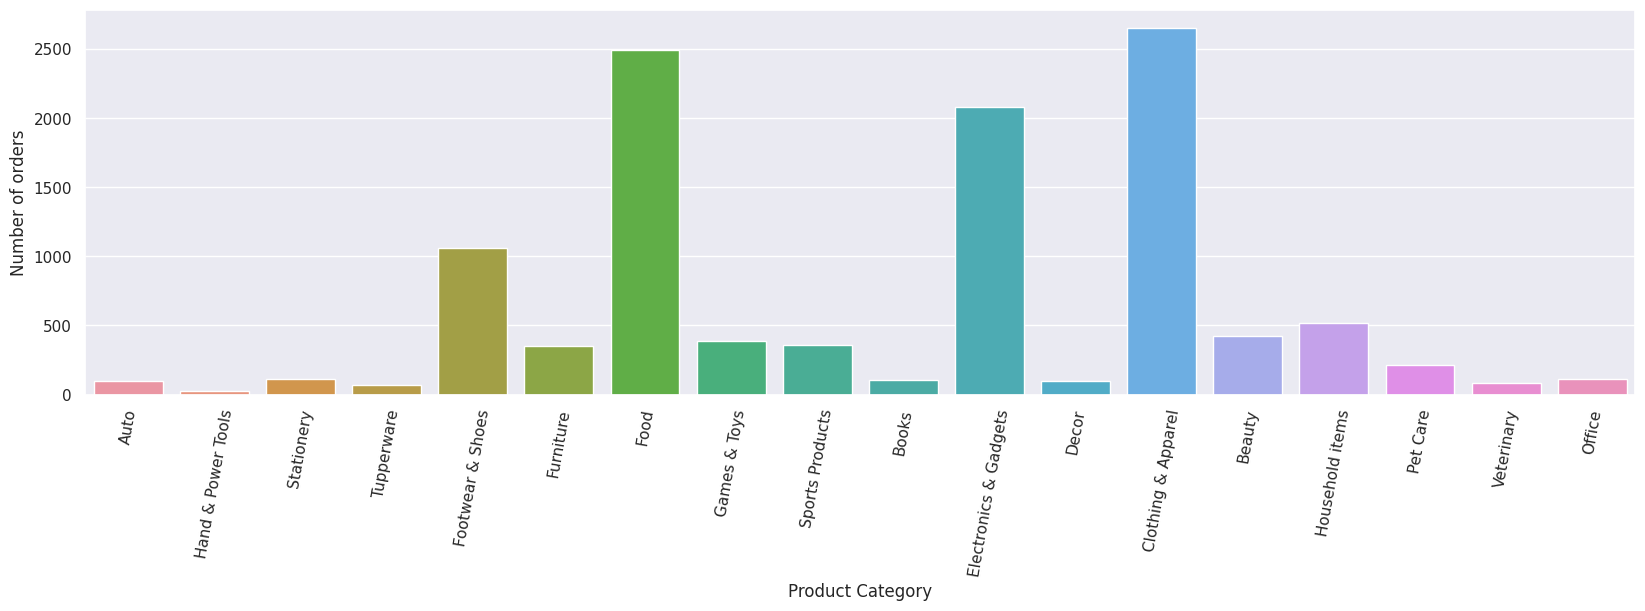

In [45]:
# plot a column graph to see which products have highest orders

sns.set(rc={'figure.figsize': (20,5)})
sns.countplot(x = 'Product_Category', data = df)
plt.xlabel("Product Category")
plt.ylabel("Number of orders")
plt.xticks(rotation=80)

Text(0.5, 1.0, 'Total order count for each product on basis of Gender')

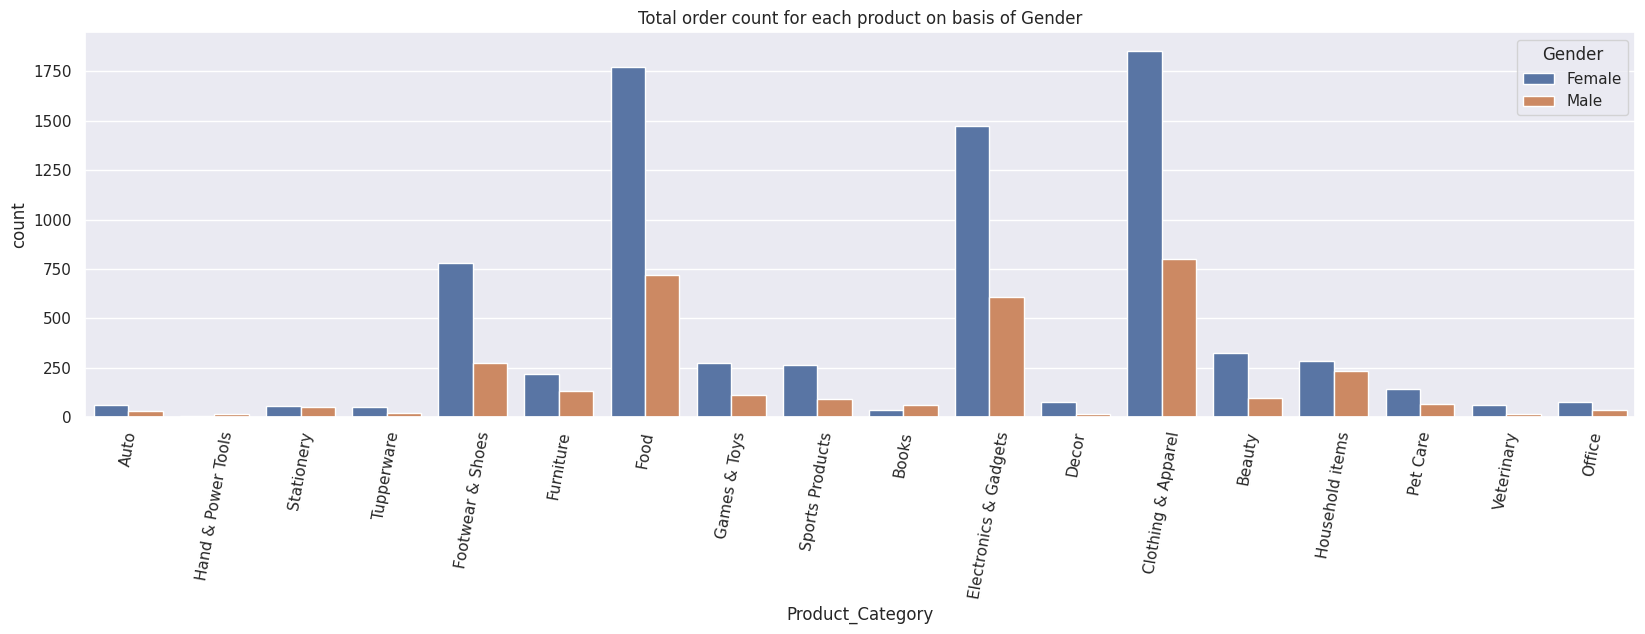

In [46]:
# plot the data of Product category on basis of Gender
sns.set(rc={'figure.figsize': (20,5)})
sns.countplot(x = 'Product_Category', data = df, hue = 'Gender')
plt.xticks(rotation=80)
plt.title("Total order count for each product on basis of Gender")

__Now will graph the data to see which products are generating most sales revenue__

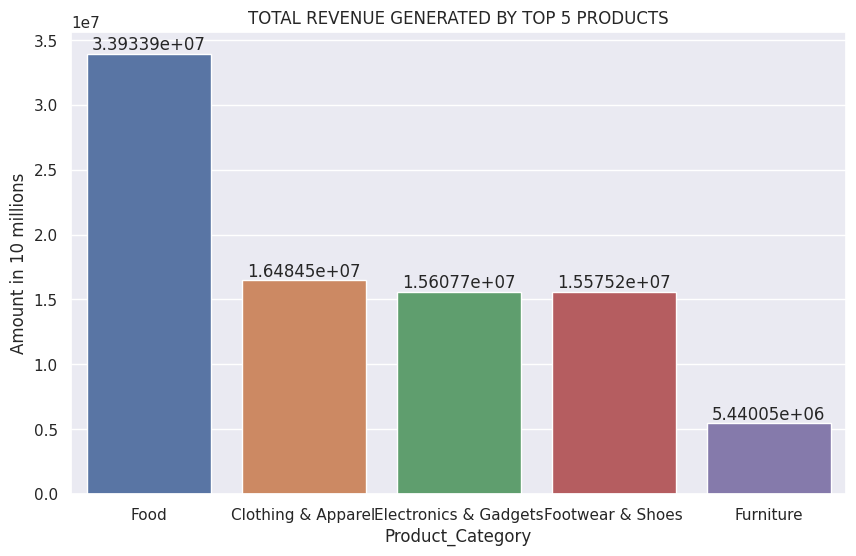

In [47]:
product = df.groupby(['Product_Category'], as_index=False).sum('Amount').sort_values(by = 'Amount', ascending = False).head(5)

#plot the data
sns.set(rc={'figure.figsize':(10,6)})
product_plot = sns.barplot(x = 'Product_Category', y = 'Amount', data = product)
plt.title("TOTAL REVENUE GENERATED BY TOP 5 PRODUCTS")
plt.ylabel("Amount in 10 millions")

for bars in product_plot.containers:
    product_plot.bar_label(bars)

__Insights from product category__

We can see a little deflection in data for the product category. For clothing & Apparel the number of order is the highest but for revenue generation Food is the highest contributor.

# Important Insights

* females are participating and are more interested in dewali sales than men. Also the purchasing power of Female is higher than male as the total sales revenue generated from female is much higher than that of male.

* Most of the customers fall in age group of 26-35. Customers from age group of 26-35 are generating the more than 40% of total Revenue

* Age group of 30 and around 30 are purchasing more than the rest of consumers. Old age people are least active buyers.

* Top 5 states of India with highest sales are Uttar Pradesh, Maharashtra, Karnataka, Dehli and Mahya Pradesh.

* we can analyze that the most of sales are coming from Unmarried and among them unmarried females are the customers with highest spendings.

* IT Sector generats the highest sales revenue and after that Aviation, Healthcare and then Banking and so on.

* We can see a little deflection in data for the product category. For clothing & Apparel the number of order is the highest but for revenue generation Food is the highest contributor.


# Conclusion

__Based on my findings I would suggest the marketting team members to increase their marketting compains specially targetting the females community in the society.__